# Supplementary Figure S14: `s14_sweep_gallery_venus`

**Accentuation sweep galleries (venus).** Here we show, for each monkey, example accentuated stimuli for three recorded sites (one seed image of the ten is chosen for plotting per site). Rows represent the ten models and columns represent four target levels along each model's accentuation axis (strong suppress, weak suppress, weak drive, strong drive). Because the columns walk the same suppress-to-drive sweep for every model, the grid exposes how different models modify the same image to achieve the target response. Images are the raw synthesized accentuation stimuli; the level ordering per (model, site, seed) is taken from that site-model's personalized sweep.

Rendered by `figures/supplementary/sup_sweep_gallery.py`; the PNG written below is pixel-identical to the manuscript file `s14_sweep_gallery_venus.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_sweep_gallery import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir), monkey='venus')
print(png)

venus    span_ok=True  saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s14_sweep_gallery_venus.png
ALL sweeps span suppress->drive: True
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s14_sweep_gallery_venus.png


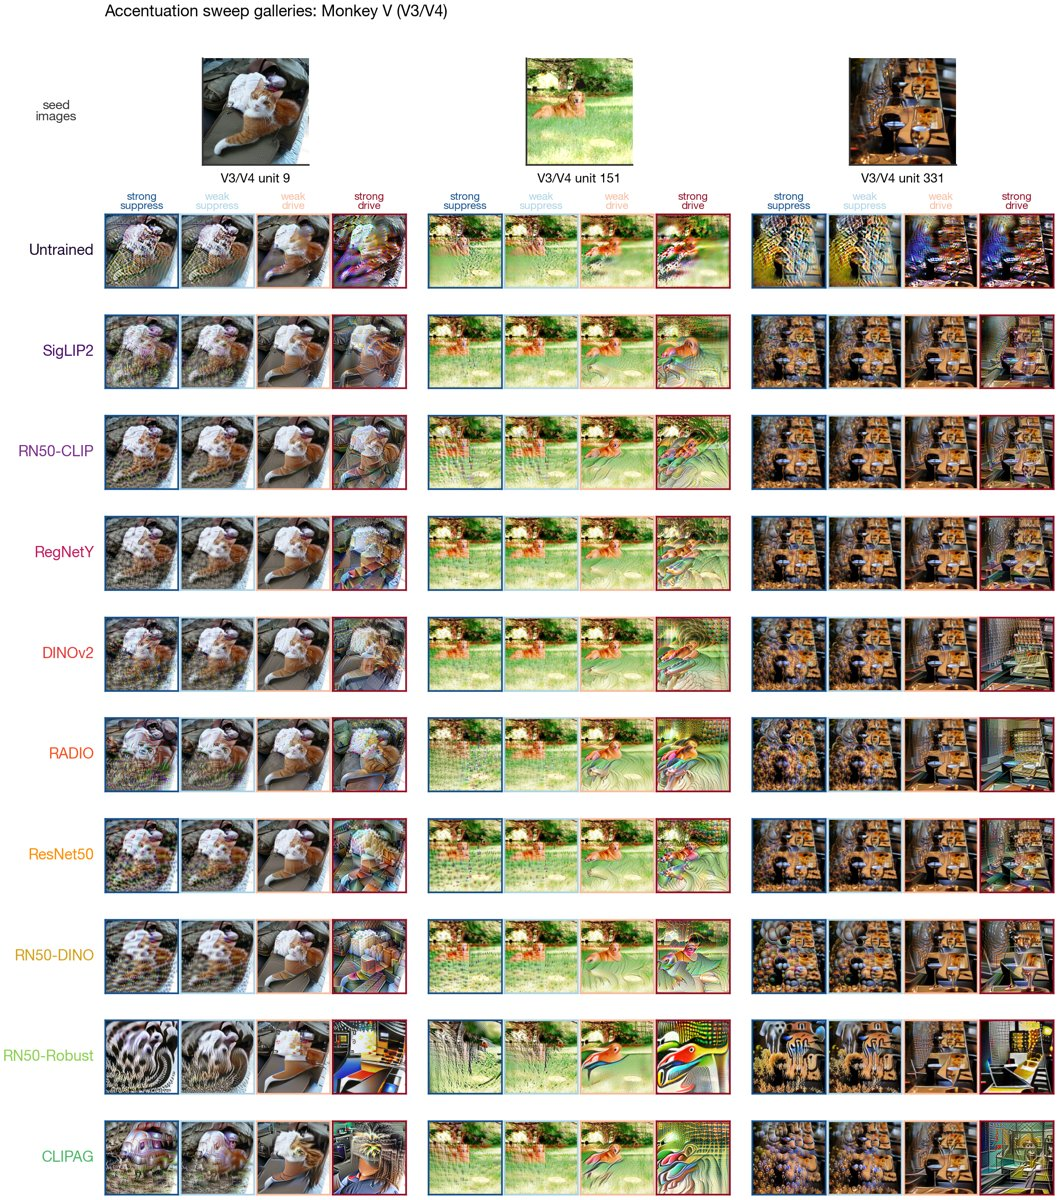

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))